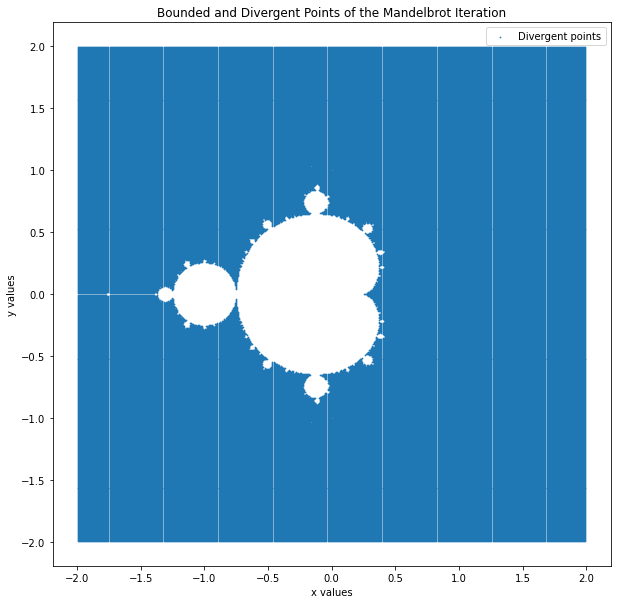

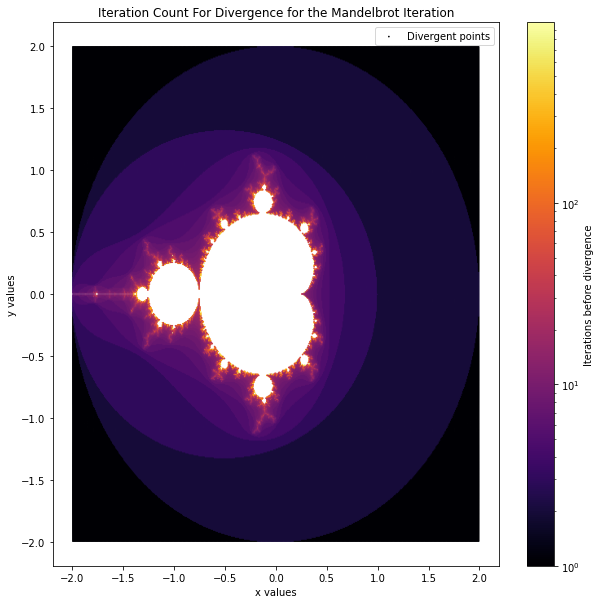

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import check_divergence as check
from scipy.integrate import solve_ivp

# Question 1
x = np.linspace(-2, 2, 500, endpoint=False)[1:]
y = np.linspace(-2, 2, 500, endpoint=False)[1:]

points = []
for first_value in x:
    for second_value in y:
        points.append((first_value, second_value))

diverged = []
#not_diverged = []
iteration = []

for values in points:
    if check.if_diverge(values) != False:
        diverged.append(values)
        iteration.append(check.if_diverge(values))
    #else:
        #not_diverged.append(values)

x_diverged = []
y_diverged = []
for point in diverged:
    x_diverged.append(point[0])
    y_diverged.append(point[1])

#print(max(iteration))    

#x_not_diverged = []
#y_not_diverged = []
#for point in not_diverged:
    #x_not_diverged.append(point[0])
    #y_not_diverged.append(point[1])

plt.figure(figsize=(10,10))

plt.scatter(
    x_diverged,
    y_diverged,
    s=0.5,
    label="Divergent points"
)

plt.xlabel("x values")
plt.ylabel("y values")
plt.title("Bounded and Divergent Points of the Mandelbrot Iteration")

plt.legend()

plt.savefig("mandelbrot_points.pdf", bbox_inches="tight")
plt.show()


plt.figure(figsize=(10,10))

scatter = plt.scatter(
    x_diverged,
    y_diverged,
    s=0.5,
    c=iteration,
    cmap='inferno',
    norm=colors.LogNorm(vmin=1, vmax=max(iteration)),
    label="Divergent points"
)

plt.xlabel("x values")
plt.ylabel("y values")
plt.title("Iteration Count For Divergence for the Mandelbrot Iteration")

plt.legend()

cbar = plt.colorbar(scatter)
cbar.set_label("Iterations before divergence")

plt.savefig("mandelbrot_iterations.pdf", bbox_inches="tight")
plt.show()

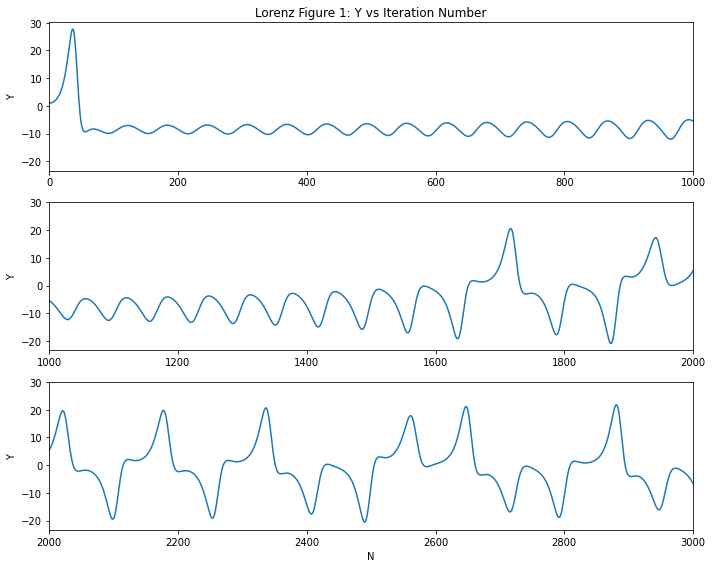

In [2]:
# Question 2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import check_divergence as check
from scipy.integrate import solve_ivp
def Lorenz(t, w, o, r, b):
    """
    Computes the derivatives of the Lorenz system for a given state vector
    W = [X, Y, Z] and parameters sigma, r, and b.

    The Lorenz system is defined by the coupled differential equations

    dX/dt = -sigma(X - Y)
    dY/dt = rX - Y - XZ
    dZ/dt = -bZ + XY

    where X, Y, and Z are dimensionless variables describing the state
    of the system.

    Returns the derivatives [dX/dt, dY/dt, dZ/dt] corresponding to the
    input state vector W.
    """
    x = w[0]
    y = w[1]
    z = w[2]
    dxdt = -1 * o * (x - y)
    dydt = r * x - y - x * z
    dzdt = -1 * b * z + x * y
    return [dxdt, dydt, dzdt]

sol = solve_ivp(Lorenz, (0,60), [0,1,0], args=[10,28,8/3], dense_output=True)
dt = 0.01
t_fig1 = np.arange(0, 30 + dt, dt)

W_fig1 = sol.sol(t_fig1)

Y_fig1 = W_fig1[1]
N_fig1 = t_fig1 / dt

plt.figure(figsize=(10, 8))

# First 1000 iterations
plt.subplot(3, 1, 1)
plt.plot(N_fig1, Y_fig1)
plt.xlim(0, 1000)
plt.ylabel("Y")
plt.title("Lorenz Figure 1: Y vs Iteration Number")

# Second 1000 iterations
plt.subplot(3, 1, 2)
plt.plot(N_fig1, Y_fig1)
plt.xlim(1000, 2000)
plt.ylabel("Y")

# Third 1000 iterations
plt.subplot(3, 1, 3)
plt.plot(N_fig1, Y_fig1)
plt.xlim(2000, 3000)
plt.xlabel("N")
plt.ylabel("Y")

plt.tight_layout()
plt.savefig("lorenz_fig1.pdf", bbox_inches="tight")
plt.show()

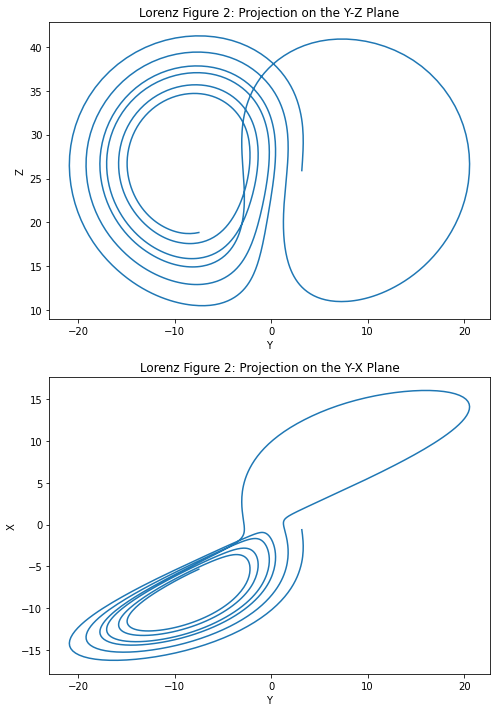

In [3]:
t_fig2 = np.linspace(14, 19, 1000)
W_fig2 = sol.sol(t_fig2)

X_fig2 = W_fig2[0]
Y_fig2 = W_fig2[1]
Z_fig2 = W_fig2[2]

plt.figure(figsize=(7, 10))

# Top plot: Y-Z projection
plt.subplot(2, 1, 1)
plt.plot(Y_fig2, Z_fig2)
plt.xlabel("Y")
plt.ylabel("Z")
plt.title("Lorenz Figure 2: Projection on the Y-Z Plane")

# Bottom plot: Y-X projection
plt.subplot(2, 1, 2)
plt.plot(Y_fig2, X_fig2)
plt.xlabel("Y")
plt.ylabel("X")
plt.title("Lorenz Figure 2: Projection on the Y-X Plane")

plt.tight_layout()
plt.savefig("lorenz_fig2.pdf", bbox_inches="tight")
plt.show()

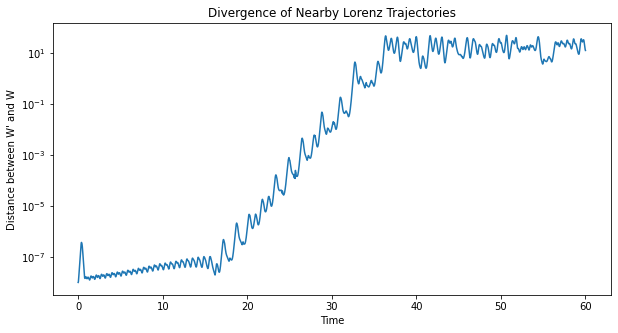

In [4]:
# Slightly diff initial condition
sigma = 10.0
r = 28.0
b = 8.0 / 3.0
W0 = np.array([0.0, 1.0, 0.0])
t_span = (0, 60)

W0_prime = W0 + np.array([0.0, 1e-8, 0.0])

sol_prime = solve_ivp(
    Lorenz,
    t_span,
    W0_prime,
    args=(sigma, r, b),
    dense_output=True
)

t_compare = np.linspace(0, 60, 6000)

W = sol.sol(t_compare)
W_prime = sol_prime.sol(t_compare)

distance = np.sqrt(
    (W_prime[0] - W[0])**2 +
    (W_prime[1] - W[1])**2 +
    (W_prime[2] - W[2])**2
)

plt.figure(figsize=(10, 5))
plt.semilogy(t_compare, distance)
plt.xlabel("Time")
plt.ylabel("Distance between W' and W")
plt.title("Divergence of Nearby Lorenz Trajectories")
plt.savefig("lorenz_divergence.pdf", bbox_inches="tight")
plt.show()